<a href="https://colab.research.google.com/github/skyline554/-1/blob/main/%EA%B3%BC%EC%A0%9C2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. 아버지의 키가 자녀의 키에 미치는 영향을 분석하고자 합니다.1) 독립 변수 X를 father로, 종속 변수 Y를 height로 설정하여 단순 선형 회귀 모델을 추정하시오.
2) 추정된 모델의 기울기(Slope)와 y절편(Intercept)을 출력하세요.
3)

데이터의 산포도(Scatter plot)와 함께 추정된 회귀선(Regression Line)을 그래프로 그리세요.



2. 자녀의 키는 부모의 키뿐만 아니라 자녀의 성별에도 큰 영향을 받습니다.
1) gender 컬럼을 수치형 데이터로 변환하세요 (예: M은 1, F은 0).
2) father, mother, gender 세 가지 변수를 모두 독립 변수로 사용하여 자녀의 키(height)를 예측하는 다중 회귀 모델을 만드세요.


3. 이 문제는 회귀분석의 핵심 원리인 '평균으로의 회귀'를 이해하기 위한 문제입니다. 독립 변수를 father, 종속 변수를 height로 하여 다음을 수행하세요.
1) 두 변수의 평균과 표준편차, 그리고 상관계수를 각각 구하세요.
2) 다음 두 직선의 기울기를 계산하세요.

표준편차선 (SD Line): 두 변수의 흩어짐 정도를 그대로 반영하는 선으로, 기울기는 s_y/s_x 입니다.
회귀선 (Regression Line): 오차 제곱합을 최소화하는 선으로, 기울기는 r X s_y/s_x   입니다.

3) 계산 결과, 회귀선의 기울기가 표준편차선의 기울기보다 더 완만하게 나타날 것입니다. 왜 회귀선의 기울기는 표준편차선의 기울기보다 작을 수밖에 없는지, '평균으로의 회귀(Regression toward the mean)' 개념을 사용하여 파이썬 코드 결과와 함께 설명하세요.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

galton_df = pd.read_csv('/galton.csv')
#galton_df.head()

                            OLS Regression Results                            
Dep. Variable:                 height   R-squared:                       0.076
Model:                            OLS   Adj. R-squared:                  0.075
Method:                 Least Squares   F-statistic:                     73.51
Date:                Thu, 09 Apr 2026   Prob (F-statistic):           4.35e-17
Time:                        13:56:50   Log-Likelihood:                -2384.3
No. Observations:                 898   AIC:                             4773.
Df Residuals:                     896   BIC:                             4782.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     39.1104      3.227     12.120      0.0

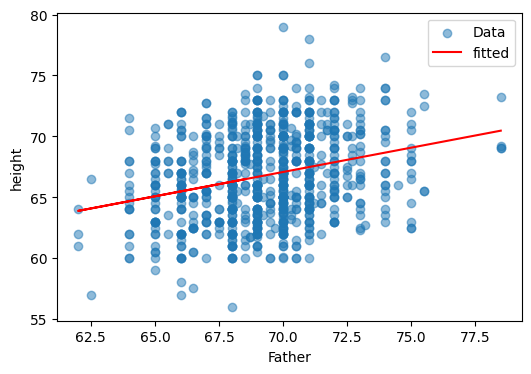

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf

# 1) 독립 변수 X를 father로, 종속 변수 Y를 height로 설정하여 단순 선형 회귀 모델을 추정하시오
model = smf.ols(formula = 'height ~ father', data = galton_df)
result = model.fit()
print(result.summary())

# 2) 추정된 모델의 기울기(Slope)와 y절편(Intercept)을 출력하세요.
print(f"\n추정된 모델의 기울기 (Slope): {result.params['father']:.4f}")
print(f"추정된 모델의 y절편 (Intercept): {result.params['Intercept']:.4f}")

# 3) 데이터의 산포도(Scatter plot)와 함께 추정된 회귀선(Regression Line)을 그래프로 그리세요.

slope, intercept = stats.linregress(galton_df['father'], galton_df['height'])[:2]

plt.figure(figsize=(6, 4))
plt.scatter(galton_df['father'], galton_df['height'], label='Data', alpha=0.5)
plt.plot(galton_df['father'], slope * galton_df['father'] + intercept, color = 'red', label = "fitted")
plt.xlabel("Father")
plt.ylabel("height")
plt.legend()
# plt.grid(True)
plt.show()

In [26]:
import statsmodels.formula.api as smf

# 1) gender 컬럼을 수치형 데이터로 변환하세요 (예: M은 1, F은 0).
galton_df['gender_numeric'] = galton_df['gender'].map({'M': 1, 'F': 0})

# 2) father, mother, gender 세 가지 변수를 모두 독립 변수로 사용하여 자녀의 키(height)를 예측하는 다중 회귀 모델을 만드세요.
model = smf.ols(formula='height ~ father + mother + gender_numeric', data=galton_df)
result = model.fit()
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                 height   R-squared:                       0.640
Model:                            OLS   Adj. R-squared:                  0.638
Method:                 Least Squares   F-statistic:                     529.0
Date:                Thu, 09 Apr 2026   Prob (F-statistic):          1.33e-197
Time:                        13:28:05   Log-Likelihood:                -1961.4
No. Observations:                 898   AIC:                             3931.
Df Residuals:                     894   BIC:                             3950.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         15.3448      2.747      5.

In [28]:
import numpy as np
import pandas as pd

# 1) 두 변수의 평균과 표준편차, 그리고 상관계수를 각각 구하세요.

# 아버지 키(father)와 자녀 키(height)의 평균
mean_father = galton_df['father'].mean()
mean_height = galton_df['height'].mean()

# 아버지 키(father)와 자녀 키(height)의 표준편차
std_father = galton_df['father'].std()
std_height = galton_df['height'].std()

# 아버지 키(father)와 자녀 키(height)의 상관계수
correlation = galton_df['father'].corr(galton_df['height'])

print(f"아버지 키 평균: {mean_father:.2f}")
print(f"자녀 키 평균: {mean_height:.2f}")
print(f"아버지 키 표준편차: {std_father:.2f}")
print(f"자녀 키 표준편차: {std_height:.2f}")
print(f"아버지 키와 자녀 키의 상관계수: {correlation:.4f}")

# 2) 다음 두 직선의 기울기를 계산하세요.

# 표준편차선 (SD Line) 기울기
sd_line_slope = std_height / std_father

# 회귀선 (Regression Line) 기울기
regression_line_slope = correlation * (std_height / std_father)

print(f"표준편차선 (SD Line) 기울기: {sd_line_slope:.4f}")
print(f"회귀선 (Regression Line) 기울기: {regression_line_slope:.4f}")

#계산 결과, 회귀선의 기울기가 표준편차선의 기울기보다 더 완만하게 나타날 것입니다. 왜 회귀선의 기울기는 표준편차선의 기울기보다 작을 수밖에 없는지, '평균으로의 회귀(Regression toward the mean)' 개념을 사용하여 파이썬 코드 결과와 함께 설명하세요.



아버지 키 평균: 69.23
자녀 키 평균: 66.76
아버지 키 표준편차: 2.47
자녀 키 표준편차: 3.58
아버지 키와 자녀 키의 상관계수: 0.2754
표준편차선 (SD Line) 기울기: 1.4504
회귀선 (Regression Line) 기울기: 0.3994


### 계산 결과, 회귀선의 기울기가 표준편차선의 기울기보다 더 완만하게 나타날 것입니다. 왜 회귀선의 기울기는 표준편차선의 기울기보다 작을 수밖에 없는지, '평균으로의 회귀(Regression toward the mean)' 개념을 사용하여 파이썬 코드 결과와 함께 설명하세요.

- 왜 외귀선의 기울기는 표준편차선의 기울기보다 작을 수밖에 없는 이유
  - 회귀선의 기울기가 표준편차선(SD Line)보다 작을 수밖에 없는 이유는 상관계수 $r$의 절대값이 1보다 작거나 같기 때문이다.
  - 수학적인 이유로는 기울기 공식을 보면 두 변수가 완벽하게 일치($r=1$)하지 않는 한, 회귀선은 항상 표준편차에 상관계수 $r$만큼의 축수를 가하게 된다.$r<1$이므로 회귀선의 기울기는 반드시 더 작아진다.
    - 표준편차 기울기: $ s_y/s_x $
    - 회귀선 기울기: $r(s_y/s_x)$
- '평균으로의 회귀(Regression toward the mean)' 개념을 사용하여 파이썬 코드 결과와 함께 설명하세요.
  - 계산 결과를 보면 회귀선의 기울기(0.3994)가 표준편차선의 기울기(1.4504)보다 훨씬 완만하다는 것을 알 수 있습니다. 이 현상은 통계학의 중요한 원리인 '평균으로의 회귀(Regression toward the mean)' 때문에 발생합니다.

